In [ ]:
# TODO Save trial.user_attr range of parameters
# TODO For neuronal network visualizate by epoch
# TODO Summary protocol

In [34]:
from utilsOptuna import remove_study_from_storage

remove_study_from_storage('sqlite:///optuna_DL_exercise.db', 'resnet18_pretrained_images1_pruner')

Study 'resnet18_pretrained_images1_pruner' deleted successfully


In [28]:
import optuna
from utilsOptuna import info_studies_from_storage, user_attr_study, get_info_runs, plot_slice, optuna_results

storage = 'sqlite:///optuna_DL_exercise.db'
print(f"Storage: {storage}")
print(info_studies_from_storage(storage)) # for a storage(project) show studies info
print("\n")

storage = 'sqlite:///optuna_DL_exercise.db'
study_name = 'resnet18_pretrained_images1'
study = optuna.load_study(
    study_name = study_name,
    storage = storage
)

# get info for a study
print(f"Storage: {storage}")
print(f"Study: {study_name}")
user_attr_study(study) # for a study show info
print(f"Total number of trials -- {len(study.trials)}\n") # Total number of trials

# get info for runs of a study
print(f"Storage: {storage}")
print(f"Study: {study_name}")
print(get_info_runs(study.trials)) # info by runs (set of trials)

print("\n")
# output for best_trial
print(f"Storage: {storage}")
print(f"Study: {study_name}")
optuna_results(study)

print(study.pruner)

Storage: sqlite:///optuna_DL_exercise.db


ValueError: Record does not exist.

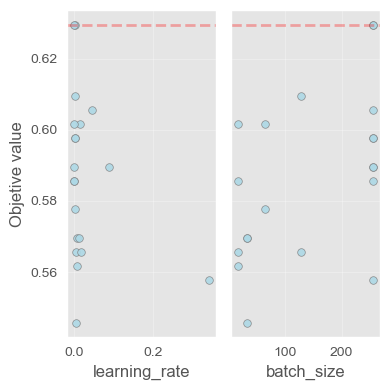

TypeError: Input z must be 2D, not 1D

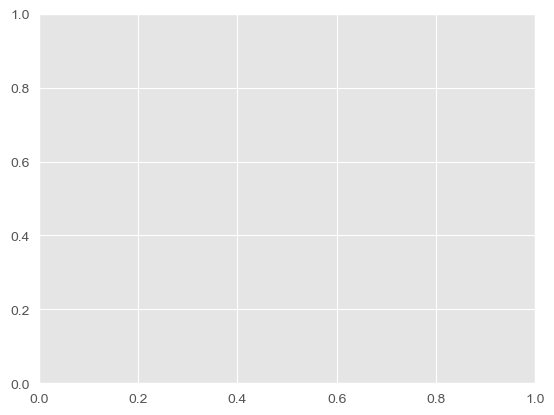

In [31]:
import optuna
from utilsOptuna import plot_slice

# Load to analize results
study = optuna.load_study(
    study_name='resnet18_pretrained_images1',
    storage='sqlite:///optuna_DL_exercise.db'
)

plot_slice(study) # Slice plot param vs objetiveValue

from utilsOptuna import get_info_trials
import seaborn as sns
import matplotlib.pyplot as plt
import math
# TODO True contour plot based on weights not point density
def plot_contour(study, params):
    trials = study.trials
    df = get_info_trials(trials)
    df_complete = df[df['state'] == 1].copy()
    df_complete['score'] = df_complete['values'].apply(lambda x: x[0] if len(x) > 0 else None)
    y_values = list(map(lambda x: math.log10(x), df_complete[params[1]]))
    plt.contourf(df_complete[params[0]], y_values, df_complete['score'], 20, cmap='RdGy')
    plt.colorbar()
    sns.set_style("white")
    #sns.kdeplot(x=df_complete[params[0]], y=y_values, weights=df_complete['score'],
    #            cmap="Blues", fill=True, bw_adjust=0.8, levels=15, thresh=0.1)

    # Add points
    plt.scatter(x=df_complete[params[0]], y=y_values, 
           color='red', alpha=0.6, s=30, edgecolor='black', linewidth=0.5)

    plt.show()

    
plot_contour(study, params=['batch_size', 'learning_rate']) # 2D contour plot
#optuna.visualization.matplotlib.plot_contour(study, params=['dropout_rate', 'batch_size']) # 2D contour plot
optuna.visualization.matplotlib.plot_contour(study, params=['batch_size', 'learning_rate']) # 2D contour plot

# TODO When input [] return all parameters
# TODO Make custom plot_contour. Highlight best result.
# TODO How to calculate importance features. Is strange? Most importance to max_depth and n_estimators?
#optuna.visualization.matplotlib.plot_param_importances(study,evaluator=optuna.importance.FanovaImportanceEvaluator())
# TODO Visualizate training/validation by epoch

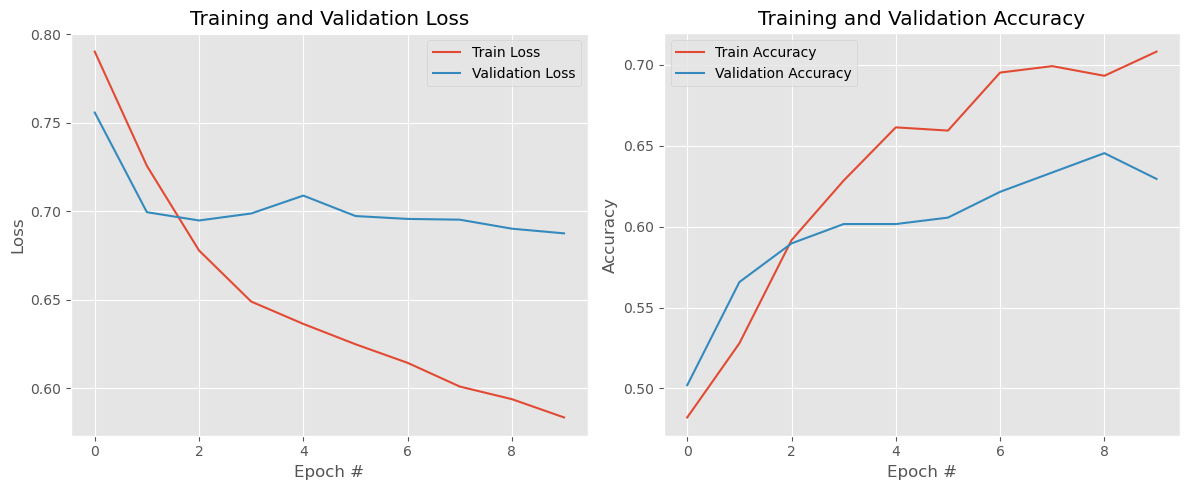

In [4]:
import optuna
from utilsOptuna import plot_train_nn

# Load to analize results
study = optuna.load_study(
    study_name='resnet18_pretrained_images1',
    storage='sqlite:///optuna_DL_exercise.db'
)

trial = study.best_trial

plot_train_nn(trial)
    

In [33]:
import numpy as np
def f(x, y):
    return np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)

x = np.linspace(0, 5, 50)
y = np.linspace(0, 5, 40)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)
Z

array([[-0.83907153, -0.83470697, -0.8216586 , ...,  0.8956708 ,
         0.68617261,  0.41940746],
       [-0.83907153, -0.8275558 , -0.80744041, ...,  0.93467448,
         0.77467433,  0.55894214],
       [-0.83907153, -0.820263  , -0.79266951, ...,  0.98503397,
         0.88847607,  0.73757604],
       ...,
       [-0.83907153, -0.48696962, -0.02692065, ...,  0.98525345,
         0.79584263,  0.46799565],
       [-0.83907153, -0.47558005, -0.00130271, ...,  0.93488414,
         0.6993547 ,  0.37933079],
       [-0.83907153, -0.46410908,  0.02431613, ...,  0.89579384,
         0.65690314,  0.40107702]], shape=(40, 50))